Gain_k_1.5 -> Max Cross-Track Error: 1.949m, RMSE: 0.359m


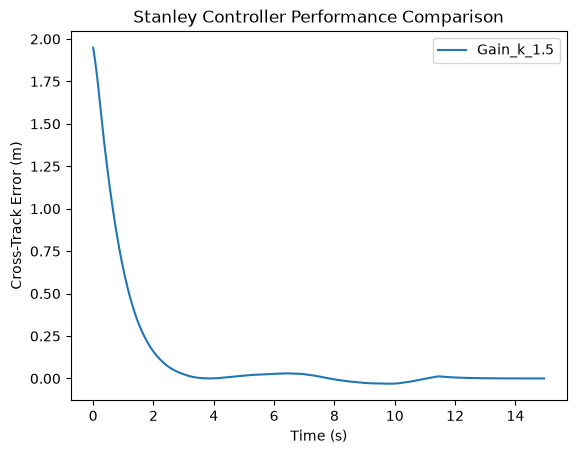

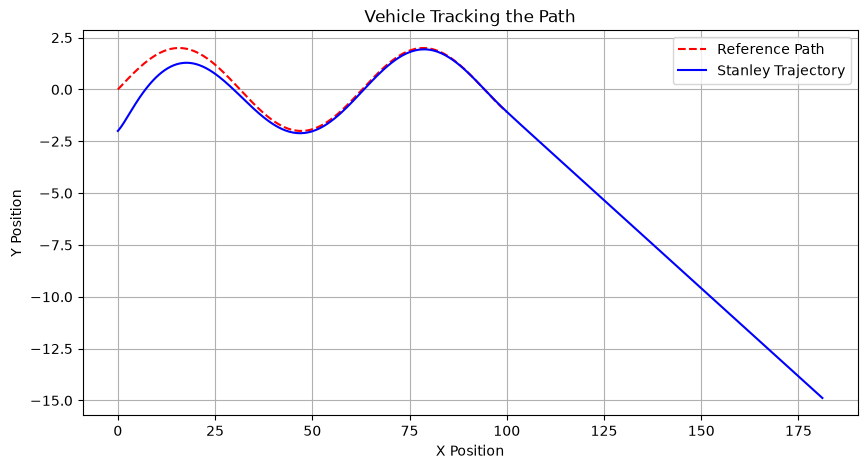

In [13]:
# !pip install numpy pandas matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class KinematicBicycleModel:
    def __init__(self, x=0.0, y=0.0, yaw=0.0, v=0.0, L=2.9):
        self.x = x
        self.y = y
        self.yaw = yaw
        self.v = v
        self.L = L  # Wheelbase

    def update(self, a, delta, dt):
        # Limit steering angle to realistic bounds (e.g., +/- 30 degrees)
        delta = np.clip(delta, -np.radians(30), np.radians(30))
        
        self.x += self.v * np.cos(self.yaw) * dt
        self.y += self.v * np.sin(self.yaw) * dt
        self.yaw += (self.v / self.L) * np.tan(delta) * dt
        self.v += a * dt

class StanleyController:
    def __init__(self, k=0.5, ks=1.0):
        self.k = k
        self.ks = ks

    def compute_steering(self, vehicle, path_x, path_y, path_yaw):
            # 1. Find the closest point on the path to the FRONT axle
            fx = vehicle.x + vehicle.L * np.cos(vehicle.yaw)
            fy = vehicle.y + vehicle.L * np.sin(vehicle.yaw)
            
            dx = [fx - x for x in path_x]
            dy = [fy - y for y in path_y]
            distances = np.hypot(dx, dy)
            target_idx = np.argmin(distances)

            # 2. Correct Cross-Track Error calculation
            # Vector from the path segment point to the front axle
            dx_front = fx - path_x[target_idx]
            dy_front = fy - path_y[target_idx]
            
            # Cross product or perpendicular vector math to find the true lateral sign
            # This tells us if we are to the left or right of the path's heading vector
            path_vec_x = np.cos(path_yaw[target_idx])
            path_vec_y = np.sin(path_yaw[target_idx])
            
            # A standard 2D cross product z-value gives us the exact lateral error sign
            error_front_axle = dx_front * path_vec_y - dy_front * path_vec_x

            # 3. Correct Heading Error (Path Yaw minus Vehicle Yaw)
            yaw_error = path_yaw[target_idx] - vehicle.yaw
            
            # Normalize yaw error to always be within [-pi, pi] so the car doesn't spin 360 degrees
            yaw_error = np.arctan2(np.sin(yaw_error), np.cos(yaw_error))

            # 4. Stanley Control Law
            crosstrack_steering = np.arctan2(self.k * error_front_axle, vehicle.v + self.ks)
            delta = yaw_error + crosstrack_steering
            
            return delta, error_front_axle

# --- Simulation Runner ---
def run_simulation(path_x, path_y, path_yaw, k_gain, target_speed=10.0):
    vehicle = KinematicBicycleModel(x=path_x[0], y=path_y[0] - 2.0, yaw=path_yaw[0], v=2.0) # start with 2m lateral offset
    controller = StanleyController(k=k_gain)
    
    dt = 0.05
    time = 0.0
    logs = []

    while time < 15.0: # Run for 15 seconds
        # Simple P controller for speed
        a = 0.5 * (target_speed - vehicle.v)
        
        # Compute control
        delta, cte = controller.compute_steering(vehicle, path_x, path_y, path_yaw)
        
        # Log data
        logs.append({
            'time': time, 'x': vehicle.x, 'y': vehicle.y, 
            'yaw': vehicle.yaw, 'v': vehicle.v, 'cte': cte, 'delta': delta
        })
        
        # Update vehicle physics
        vehicle.update(a, delta, dt)
        time += dt
        
    return pd.DataFrame(logs)

# Example: A simple straight path with a lane change or curve
path_x = np.linspace(0, 100, 1000)
path_y = np.sin(path_x / 10.0) * 2.0  # S-curve path
path_yaw = np.gradient(path_y, path_x)

gains_to_test = [0.1, 0.5, 1.5]
results = {}

for g in gains_to_test:
    run_id = f"Gain_k_{g}"
    results[run_id] = run_simulation(path_x, path_y, path_yaw, k_gain=g)

for run_id, df in results.items():
    rmse = np.sqrt((df['cte'] ** 2).mean())
print(f"{run_id} -> Max Cross-Track Error: {df['cte'].abs().max():.3f}m, RMSE: {rmse:.3f}m")
    
# Plotting Cross-Track Error over time for comparison
plt.plot(df['time'], df['cte'], label=run_id)

plt.xlabel('Time (s)')
plt.ylabel('Cross-Track Error (m)')
plt.legend()
plt.title('Stanley Controller Performance Comparison')
plt.show()

# --- Simulation Runner ---
def run_simulation(path_x, path_y, path_yaw, k_gain, target_speed=10.0):
    vehicle = KinematicBicycleModel(x=path_x[0], y=path_y[0] - 2.0, yaw=path_yaw[0], v=2.0)
    controller = StanleyController(k=k_gain)
    
    dt = 0.05
    time = 0.0
    logs = []

    while time < 20.0:
        a = 0.5 * (target_speed - vehicle.v)
        delta, cte = controller.compute_steering(vehicle, path_x, path_y, path_yaw)
        
        logs.append({
            'time': time, 'x': vehicle.x, 'y': vehicle.y, 
            'yaw': vehicle.yaw, 'v': vehicle.v, 'cte': cte, 'delta': delta
        })
        
        vehicle.update(a, delta, dt)
        time += dt
        
    return pd.DataFrame(logs)

# --- 1. Create an S-Curve Path to Test On ---
path_x = np.linspace(0, 100, 1000)
path_y = np.sin(path_x / 10.0) * 2.0  # Creates a wavy path
path_yaw = np.gradient(path_y, path_x)

# --- 2. Run the Simulation ---
results_df = run_simulation(path_x, path_y, path_yaw, k_gain=0.5)

# --- 3. Plot the Results ---
plt.figure(figsize=(10, 5))
plt.plot(path_x, path_y, 'r--', label='Reference Path')
plt.plot(results_df['x'], results_df['y'], 'b-', label='Stanley Trajectory')
plt.title('Vehicle Tracking the Path')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.legend()
plt.grid(True)
plt.show()